<a href="https://colab.research.google.com/github/beecall17/AI-ML-Learning/blob/main/Linear-Model-%5BWeek-04%5D/Linear_model_Bikal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Notebooks/Telco-Customer-Churn.csv")

# first five rows inspect
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


row:
A unique cutomer with demographic info, services subscribed to, and payment info.

Total 7043 rows with 21 columns

Churn -> target column

TotalCharges -- Object -> Float

No null values, till now!


Right skewed dataset (tenure, monthlycharges)


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


In [ ]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [ ]:
# First two rows of na on total charges. to inspect the data for imputation
df[df["TotalCharges"].isna()].head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No


In [ ]:
# 11 null values, probably deu to new customers who haven't paid their first charge, as they have 0 tenure.
# Filling with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [ ]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
# Mapping churn to 1,0
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})
df["Churn"].head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [ ]:
(df["Churn"]).value_counts(normalize=True) * 100

,proportion
Churn,
0,73.463013
1,26.536987


Imbalanced target variable with 73% retained and 27% churn.

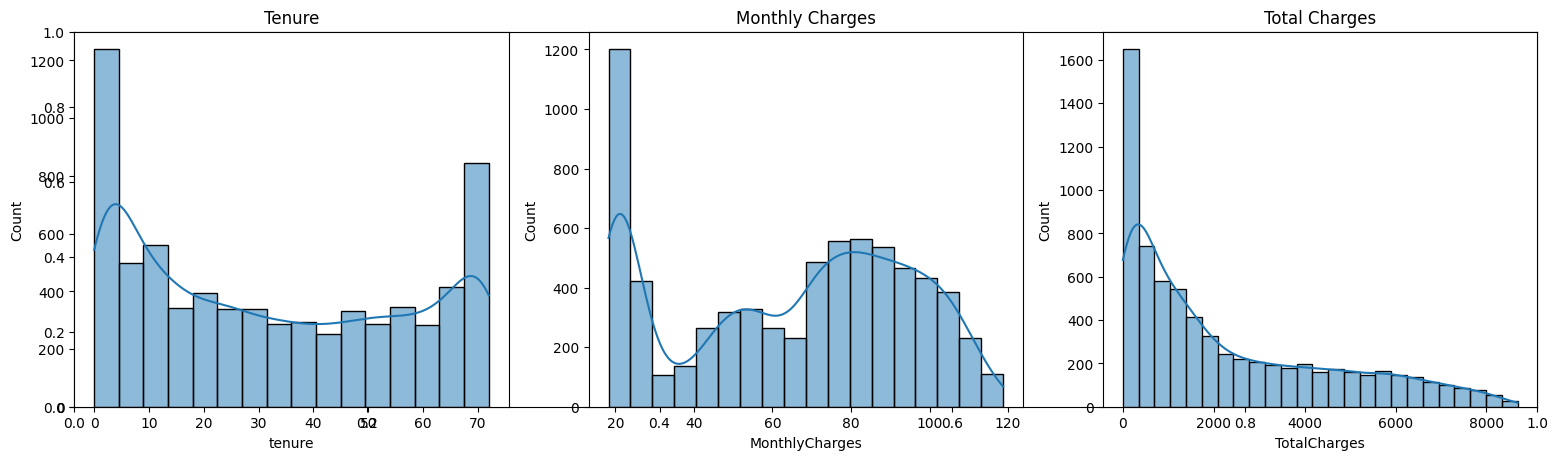

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.subplots(figsize=(16,5))
plt.subplot(1,3,1)
sns.histplot(df["tenure"],kde=True)
plt.title("Tenure")

plt.subplot(1,3,2)
sns.histplot(df["MonthlyCharges"],kde=True)
plt.title("Monthly Charges")

plt.subplot(1,3,3)
sns.histplot(df["TotalCharges"],kde=True)
plt.title("Total Charges")

plt.tight_layout()
plt.show()

**Tenure Distribution**
* Bimodel -> two peaks, one at where the users count is huge during the start the servies. This is decreased rapidly as tenure increases. The second peak at the last showint the long term - loyal customers.

**Monthly charges Distribution**

* Right skewed data.
* Huge number of customers at lower charges plans
* Good amount of customers at the slightly end range 80-100 indicating family plans.

**Total charges**
* Right skewed similar to monthly charges.


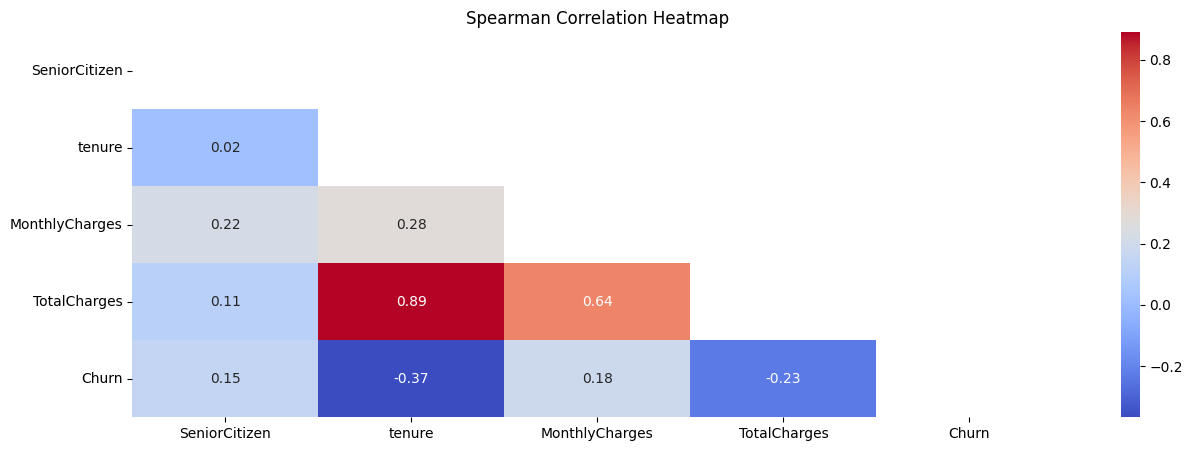

In [ ]:
import numpy as np

plt.figure(figsize=(15, 5))
corr = df.select_dtypes(include=np.number).corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", mask=mask)
plt.title('Spearman Correlation Heatmap')
plt.show()

1. High correlation (0.89) between tenure and total charges.
This can affect model predictive power.
2. Mild correlation (0.64) between totalcharges and monthlycharges.
3. tenure , total charges have negative corelation with churn.

`Removing totalcharges might produce a better model training`

Tenure and totalcharges appers to be churn reducing features.

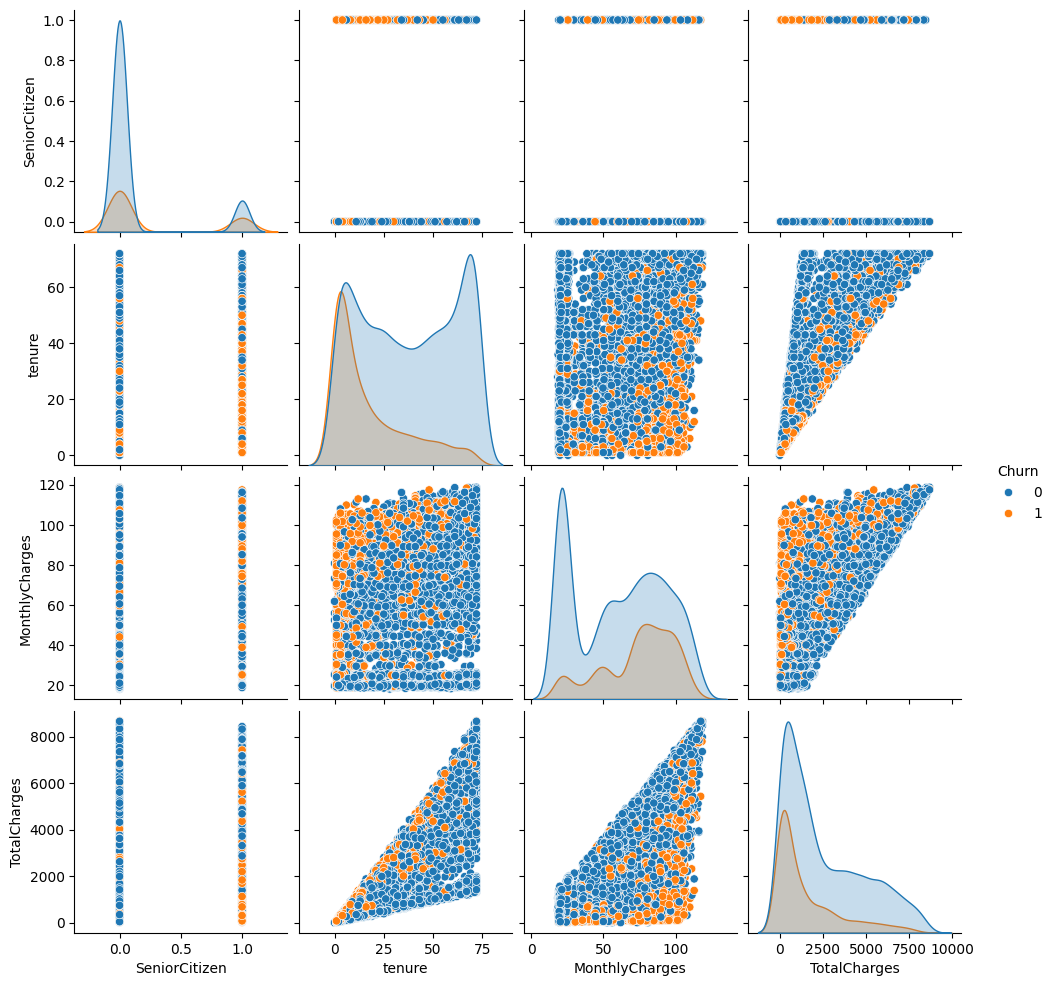

In [ ]:
# lets look roughly at features relationships

sns.pairplot(df, hue="Churn", diag_kind="kde")
plt.show()

This pair plot provides possibility of:
1. Senior citizen are more likely to churn.
2. Less tenure = more churn
3. high monthly charges = more churn
4. less total charge (same as tenure) = more churn

* All features are compact no spread is seen.
* strong positive linear relationship between tenure and total charges (correlinear) cant be determined just by looking this.

In [ ]:
# VIF calculation to see the collinearity

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numerical columns for VIF calculation, excluding the target variable 'Churn'
X = df.select_dtypes(include=np.number).drop(columns=['Churn'], errors='ignore')

# Add a constant (intercept) term to the independent variables
X_const = sm.add_constant(X)

# Create a DataFrame to store VIF values
vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns

# Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(len(X_const.columns))]

print("VIF scores:")
print(vif_data.sort_values(by='VIF', ascending=False))

VIF scores:
          feature        VIF
0           const  14.916042
4    TotalCharges   9.528163
2          tenure   5.839368
3  MonthlyCharges   3.306036
1   SeniorCitizen   1.054557


Toalcharges has 9.5 VIF (Generally VIF > 5 is consider as warning, > 10 is sever). Its close to 10.


In [ ]:
# checking VIF with no TotalCharges
X2 = df[['tenure', 'MonthlyCharges', 'SeniorCitizen']]
X2_const = sm.add_constant(X2)
vif2 = pd.DataFrame()
vif2["feature"] = X2_const.columns
vif2["VIF"] = [variance_inflation_factor(X2_const.values, i) for i in range(X2_const.shape[1])]
print(vif2)

          feature       VIF
0           const  6.288773
1          tenure  1.067205
2  MonthlyCharges  1.121267
3   SeniorCitizen  1.052649


Without Totalcharges, the VIF dropped drastically. Trained model with totalcharges likely to have worst performance.

*“Without TotalCharges, the VIF values for all features dropped dramatically – from 9.53 to below 1. Including TotalCharges alongside tenure and MonthlyCharges introduces severe multicollinearity, which makes linear model coefficients unstable, inflates variance, and degrades generalisation performance. Because TotalCharges is essentially a function of tenure × MonthlyCharges, it adds no unique information. Hence, dropping TotalCharges improves model stability and interpretability without sacrificing predictive accuracy.”*



For this assignment we will keep the total charges to see its interpretation.

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

# Identify the majority class
majority_class = df['Churn'].value_counts().idxmax()
print(f"Majority class (No Churn): {majority_class}")

# Create a prediction array where all predictions are the majority class
y_true = df['Churn']
y_pred_baseline = [majority_class] * len(y_true)

# Evaluate the baseline model
accuracy_baseline = accuracy_score(y_true, y_pred_baseline)
recall_baseline = recall_score(y_true, y_pred_baseline)
f1_baseline = f1_score(y_true, y_pred_baseline)

print(f"\nNaive Baseline Model Performance:")
print(f"Accuracy: {accuracy_baseline:.4f}")
print(f"Recall: {recall_baseline:.4f}")
print(f"F1 Score: {f1_baseline:.4f}")

Majority class (No Churn): 0

Naive Baseline Model Performance:
Accuracy: 0.7346
Recall: 0.0000
F1 Score: 0.0000


The Naive model which preditcs only no churn has 73% accuracy. 0 recall means it will not catch any Churn.

Even though model has 73% accuracy, it has no potential of predicitng churn. Accuracy along is not helpful in this dataset.

### Data Preprocessing for Model Training


In [ ]:
# Separate features (X) and target (y)
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

print("Shape of X after one-hot encoding:", X.shape)
display(X.head())

Shape of X after one-hot encoding: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [ ]:
### Splitting the Dataset (70% Train, 15% Validation, 15% Test)
from sklearn.model_selection import train_test_split

# Train 70% and temporary 30%
X_train, X_temp, y_train, y_temp = train_test_split(X,y, test_size = 0.3, random_state=42, stratify=y)

# 15% Validation, 15% Test from 30% temporary (~50%)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp, test_size=0.5, random_state = 42)



In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (4930, 30)
y_train shape: (4930,)
X_val shape: (1056, 30)
y_val shape: (1056,)
X_test shape: (1057, 30)
y_test shape: (1057,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# numeric columns (those not already one-hot encoded or target)
# 'tenure', 'MonthlyCharges', 'TotalCharges' are the main numeric features
# and 'SeniorCitizen' is binary.
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data's numeric columns
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Transform validation and test data using the SAME scaler fitted on training data
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Numeric features in X_train after scaling (first 2 rows):")
display(X_train[numeric_cols].head(2))
print("\nNumeric features in X_val after scaling (first 2 rows):")
display(X_val[numeric_cols].head(2))
print("\nNumeric features in X_test after scaling (first 2 rows):")
display(X_test[numeric_cols].head(2))

Numeric features in X_train after scaling (first 2 rows):


,tenure,MonthlyCharges,TotalCharges
5557,-1.114728,0.504286,-0.836504
2270,-1.195884,0.724189,-0.907742



Numeric features in X_val after scaling (first 2 rows):


,tenure,MonthlyCharges,TotalCharges
1560,0.264926,-0.658058,-0.223003
3320,-0.587213,-0.193451,-0.563071



Numeric features in X_test after scaling (first 2 rows):


,tenure,MonthlyCharges,TotalCharges
6611,-0.140854,0.135577,-0.149781
1125,0.264926,1.345870,0.865058


In [ ]:
from sklearn.linear_model import LogisticRegression
import time

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='lbfgs')

# Record the start time
start_time = time.time()

# Train the model
log_reg_model.fit(X_train, y_train)

# Record the end time
end_time = time.time()

# Calculate training time
training_time = end_time - start_time

print(f"Logistic Regression model trained in {training_time:.4f} seconds")

Logistic Regression model trained in 0.1811 seconds


In [ ]:
from sklearn.linear_model import RidgeClassifier
# Initialize the Ridge Classifier model
ridge_model = RidgeClassifier(random_state=42)

# Record the start time
start_time = time.time()

# Train the model
ridge_model.fit(X_train, y_train)

# Record the end time
end_time = time.time()

# Calculate training time
training_time = end_time - start_time

print(f"Ridge Classifier model trained in {training_time:.4f} seconds")

Ridge Classifier model trained in 0.1549 seconds


In [ ]:
from sklearn.linear_model import SGDClassifier
# Initialize the SGD Classifier model
sgd_model = SGDClassifier(loss='log_loss', random_state=42)

# Record the start time
start_time = time.time()

# Train the model
sgd_model.fit(X_train, y_train)

# Record the end time
end_time = time.time()

# Calculate training time
training_time = end_time - start_time

print(f"SGD Classifier model trained in {training_time:.4f} seconds")

SGD Classifier model trained in 0.1469 seconds


In logistic regression model:

*   Training time 0.1444 seconds
*   Uses Binary cross-entropy (log loss) as loss function
*   Full-batch L-BFGS as optimizer (default and useful in large dataset and uses l2 regularization, for these smaller dataset can use "liblinear" where l1 requlizarion is required.)

In Ridge Classifier:
* Training time 0.0845 sec
* Uses 'squared error' as loss function with added l2 penalty.
* Uses 'closed form' as optimizer --  it directly computes the weights using matrix algebra.

In SGD Classifier:
* Training time 0.0983 sec
* Used 'log_loss' as loss function (same as logistic regression but fitted via SGD) default penalty is l2.
* Uses 'SGD' as optimizer


SGD Classifier is fastest among all in training the model. Despite of fitting the model via SGD and using log-loss i.e., logistic regression, its the fastest. SGD is faster as it updates model parameter frequently, ofter after one training example or small batch of examples.

In [ ]:
y_pred_log_reg = log_reg_model.predict(X_val)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_val)[:, 1]

y_pred_ridge = ridge_model.predict(X_val)
# RidgeClassifier doesn't have predict_proba directly, it uses decision_function
y_score_ridge = ridge_model.decision_function(X_val)

y_pred_sgd = sgd_model.predict(X_val)
y_pred_proba_sgd = sgd_model.predict_proba(X_val)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, average_precision_score

def evaluate_model(y_true, y_pred, y_proba_or_score, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # For ROC-AUC, PR-AUC, and Log Loss, we need probabilities or decision scores
    # RidgeClassifier uses decision_function, which can be directly used for ROC-AUC and PR-AUC
    # For Log Loss, probabilities are strictly required. If not available, we might skip it or approximate.
    roc_auc = roc_auc_score(y_true, y_proba_or_score)
    pr_auc = average_precision_score(y_true, y_proba_or_score)

    # Log loss requires probabilities (between 0 and 1). decision_function output can be anything.
    # For RidgeClassifier, we cannot directly compute log_loss without converting scores to probabilities.
    # For simplicity, we'll assume y_proba_or_score are probabilities if it's not decision_function.
    # If it's a decision_function, we'll handle it carefully or note the limitation.
    try:
        logloss = log_loss(y_true, y_proba_or_score) # This assumes y_proba_or_score are probabilities
    except ValueError:
        logloss = None # Or a more sophisticated conversion for decision_function if needed

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Log Loss': logloss
    }

# Evaluate Logistic Regression
metrics_log_reg = evaluate_model(y_val, y_pred_log_reg, y_pred_proba_log_reg, 'Logistic Regression')

# Evaluate Ridge Classifier
# Note: RidgeClassifier's decision_function scores are used for ROC-AUC and PR-AUC.
# Log Loss is typically not computed directly for RidgeClassifier without probability calibration.
metrics_ridge = evaluate_model(y_val, y_pred_ridge, y_score_ridge, 'Ridge Classifier')
metrics_ridge['Log Loss'] = "N/A" # Explicitly mark as N/A as probabilities are not directly available

# Evaluate SGD Classifier
metrics_sgd = evaluate_model(y_val, y_pred_sgd, y_pred_proba_sgd, 'SGD Classifier')

# Create a DataFrame for comparison
results_df = pd.DataFrame([metrics_log_reg, metrics_ridge, metrics_sgd])

# Sort by PR-AUC (handle N/A by converting to numeric where possible, or sorting non-numeric last)
results_df['PR-AUC_sort'] = pd.to_numeric(results_df['PR-AUC'], errors='coerce')
results_df = results_df.sort_values(by='PR-AUC_sort', ascending=False).drop(columns='PR-AUC_sort')

print("\nModel Comparison Table:")
display(results_df)


Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression,0.810606,0.666667,0.576512,0.618321,0.846998,0.648289,0.41589
2,SGD Classifier,0.803030,0.643137,0.583630,0.611940,0.846580,0.648181,0.416745
1,Ridge Classifier,0.800189,0.653509,0.530249,0.585462,0.837938,0.638136,N/A


`Logistic regression` slightly beats the SGD classifier on ROC-AUC, as well as in other metrics.

While Ridge classifier is slightly behind both of them. Rdige is the first one to be dropped model as it has low recall and f1 score. And slightly behind in ROC-AUC and PR-AUC.


Among Logistic and SGD,

Since we have imbalanced target instead of relying only on Precision or Recall we choose to view the metrics from ROC-AUC and PR-AUC in both `Logistic Regression` is slightly better than SGD Classifier.

`Note:`For large dataset where compute time matters, as SGD has lower training time it would be preferred. Currently, SGD is also trained via. log_loss i.e. logistic regression.

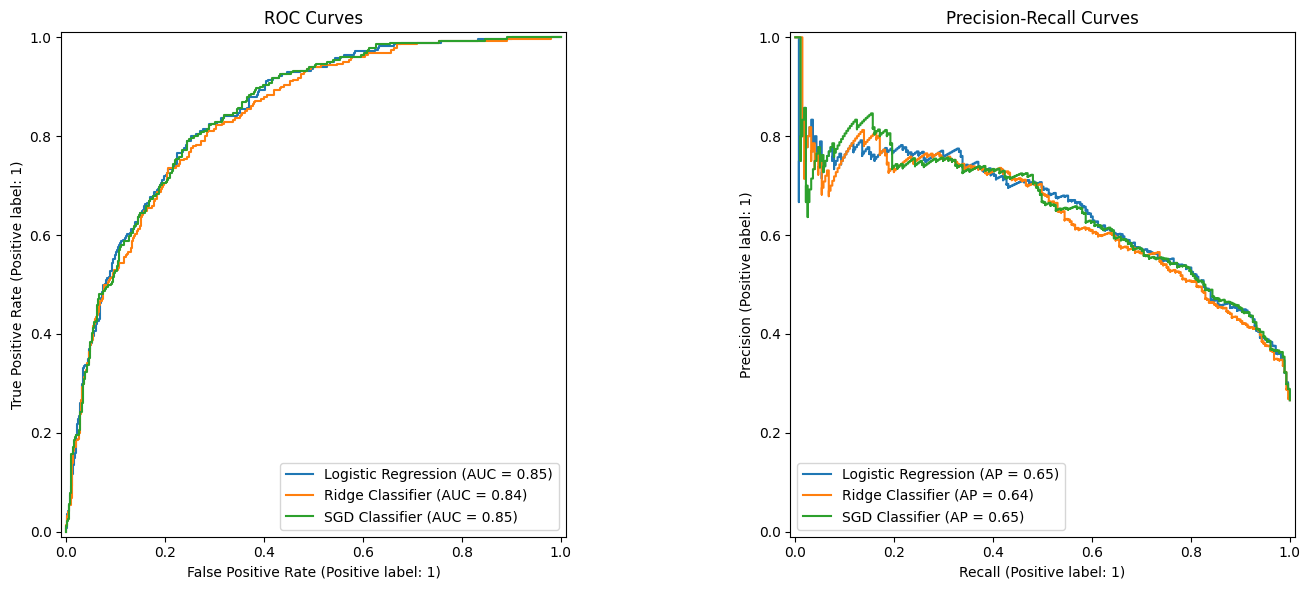

In [ ]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

plt.figure(figsize=(15, 6))

# --- ROC Curves ---
plt.subplot(1, 2, 1)
plt.title('ROC Curves')

RocCurveDisplay.from_predictions(y_val, y_pred_proba_log_reg, name='Logistic Regression', ax=plt.gca())
RocCurveDisplay.from_predictions(y_val, y_score_ridge, name='Ridge Classifier', ax=plt.gca())
RocCurveDisplay.from_predictions(y_val, y_pred_proba_sgd, name='SGD Classifier', ax=plt.gca())

# --- Precision-Recall Curves ---
plt.subplot(1, 2, 2)
plt.title('Precision-Recall Curves')

PrecisionRecallDisplay.from_predictions(y_val, y_pred_proba_log_reg, name='Logistic Regression', ax=plt.gca())
PrecisionRecallDisplay.from_predictions(y_val, y_score_ridge, name='Ridge Classifier', ax=plt.gca())
PrecisionRecallDisplay.from_predictions(y_val, y_pred_proba_sgd, name='SGD Classifier', ax=plt.gca())

plt.tight_layout()
plt.show()

**ROC curves** plot True Positive Rate (Recall) against False Positive Rate across all thresholds. While they give a good overall picture of a classifier's ability to discriminate, they can be misleading in highly imbalanced scenarios. This is because the False Positive Rate (FPR) is calculated as FP / (FP + TN), and when TN (True Negatives) are abundant (as in a skewed dataset), FPR can remain low even if the model makes a significant number of False Positives relative to the number of Actual Positives.

**PR curves**, on the other hand, plot Precision (TP / (TP + FP)) against Recall (TP / (TP + FN)). Precision is directly sensitive to the number of False Positives. In an imbalanced dataset, even a small number of False Positives can drastically reduce precision even if the number of True Positives is also small. Therefore, the PR curve provides a more realistic and often more pessimistic (but accurate) view of a model's performance on the minority class. A model with a great ROC-AUC might have a poor PR-AUC if it's struggling to achieve high precision for the positive class.

---

A model whose ROC curve lies close to the diagonal (the line from (0,0) to (1,1)) indicates that its performance is close to that of a random classifier. A perfectly random classifier would produce an ROC curve exactly on the diagonal, meaning it predicts positive and negative outcomes with equal probability, effectively performing no better than chance.

The further a model's ROC curve is from the diagonal and towards the top-left corner (TPR=1, FPR=0), the better its discriminative power.

---
Logistic Regression performs better on both ROC and PR curves.

In [ ]:
# Threshold tuning

# Get churn probabilities for the validation set from the Logistic Regression model
# y_pred_proba_log_reg was already calculated as log_reg_model.predict_proba(X_val)[:, 1]

# Combine probabilities with actual y_val to sort and get the threshold
val_results = pd.DataFrame({
    'actual': y_val,
    'probability': y_pred_proba_log_reg
})

# Sort by probability in descending order
val_results_sorted = val_results.sort_values(by='probability', ascending=False).reset_index(drop=True)

# Determine the threshold for the top 200 customers
# Assuming we want to target the top 200, so the threshold is the probability of the 200th customer
target_count = 200
if len(val_results_sorted) >= target_count:
    custom_threshold = val_results_sorted.loc[target_count - 1, 'probability']
    print(f"Custom threshold to target top {target_count} customers: {custom_threshold:.4f}")
else:
    print(f"Not enough customers ({len(val_results_sorted)}) in validation set to target top {target_count}.")
    print("Using the lowest probability as a threshold.")
    custom_threshold = val_results_sorted['probability'].min()

# --- Evaluate performance at custom threshold ---
# Make predictions using the custom threshold
y_pred_custom_threshold = (y_pred_proba_log_reg >= custom_threshold).astype(int)

precision_custom = precision_score(y_val, y_pred_custom_threshold)
recall_custom = recall_score(y_val, y_pred_custom_threshold)
f1_custom = f1_score(y_val, y_pred_custom_threshold)

print(f"\nPerformance at custom threshold ({custom_threshold:.4f}):")
print(f"  Precision: {precision_custom:.4f}")
print(f"  Recall: {recall_custom:.4f}")
print(f"  F1 Score: {f1_custom:.4f}")

# --- Evaluate performance at default 0.5 threshold ---
# y_pred_log_reg was already calculated as log_reg_model.predict(X_val)
precision_default = precision_score(y_val, y_pred_log_reg)
recall_default = recall_score(y_val, y_pred_log_reg)
f1_default = f1_score(y_val, y_pred_log_reg)

print("\nPerformance at default 0.5 threshold:")
print(f"  Precision: {precision_default:.4f}")
print(f"  Recall: {recall_default:.4f}")
print(f"  F1 Score: {f1_default:.4f}")

# Compare the number of predicted churners\
print(f"\nNumber of predicted churners at custom threshold: {np.sum(y_pred_custom_threshold)}")
print(f"Number of predicted churners at default 0.5 threshold: {np.sum(y_pred_log_reg)}")


Custom threshold to target top 200 customers: 0.5466

Performance at custom threshold (0.5466):
  Precision: 0.7000
  Recall: 0.4982
  F1 Score: 0.5821

Performance at default 0.5 threshold:
  Precision: 0.6667
  Recall: 0.5765
  F1 Score: 0.6183

Number of predicted churners at custom threshold: 200
Number of predicted churners at default 0.5 threshold: 243


**Custom Threshold (0.5466):**

* Precision: 0.7000 - This means that out of the 200 customers model predicted as churners (by setting this threshold), 70% actually churned. This is a good precision for targeted interventions.
* Recall: 0.4982 - This indicates that model correctly identified about 50% of all actual churners in the validation set. While this is precise, its missing half of the churners.
* F1 Score: 0.5821 - The F1 score, which is the harmonic mean of precision and recall, reflects a balanced performance given the higher precision and lower recall.

**Default 0.5 Threshold:**

* Precision: 0.6667 - Out of the 243 customers predicted as churners, about 66.7% actually churned. This is slightly lower than the custom threshold's precision.
* Recall: 0.5765 - This threshold captured a higher percentage of actual churners (about 57.65%) compared to the custom threshold.
* F1 Score: 0.6183 - The F1 score is higher at the default threshold, primarily due to the increased recall.
* Predicted Churners: 243 - The default threshold identified 243 potential churners, which is more than desired target of 200.

**Key Takeaways:**

* Trade-off: A classic precision-recall trade-off. The custom threshold (0.5466) prioritizes precision (identifying actual churners among those targeted) at the cost of slightly lower recall (missing more actual churners overall). This is beneficial if intervention resources are limited, and want to be highly confident that the customers target are indeed at high risk of churning.
The default 0.5 threshold provides a slightly better F1 score and recall, meaning it catches more churners overall, but with slightly lower precision and it exceeds your target budget of 200 customers.

Depending on specific business goals—whether it's to be highly efficient with limited resources (higher precision, custom threshold) or to capture as many churners as possible even if it means more false positives (higher recall, default threshold) - would choose the appropriate threshold. Given constraint of targeting the top 200, the custom threshold is directly aligned with that operational need, ensuring within budget while maintaining good precision.

- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

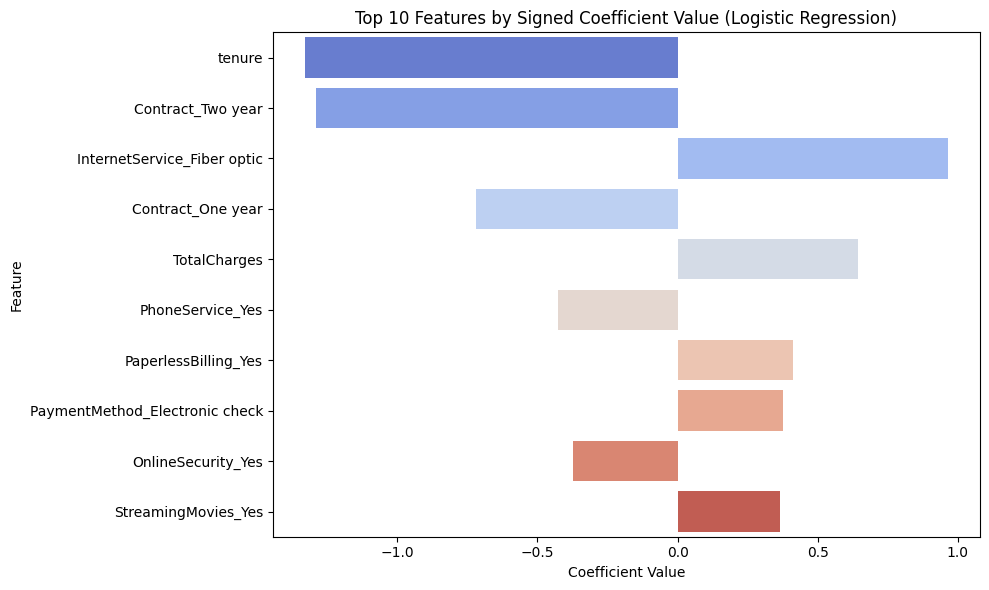

In [ ]:
# Ensure feature_importance DataFrame is available or re-create it
if 'feature_importance' not in locals() or feature_importance.empty:
    if 'log_reg_model' in locals() and 'X_train' in locals():
        coefficients = log_reg_model.coef_[0]
        feature_names = X_train.columns
        feature_importance = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': coefficients
        })
        feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
        feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)
    else:
        print("Error: 'log_reg_model' or 'X_train' not found. Please run previous cells.")
        feature_importance = pd.DataFrame() # Create an empty DataFrame to avoid errors

if not feature_importance.empty:
    # Select the top 10 features based on absolute value
    top_10_features_signed = feature_importance.head(10)

    # Plotting actual coefficients
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Coefficient', y='Feature', data=top_10_features_signed, palette='coolwarm', hue='Feature', legend=False)
    plt.title('Top 10 Features by Signed Coefficient Value (Logistic Regression)')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("Could not generate plot: feature_importance DataFrame is empty or not available.")

Based on the plot of the top 10 features by absolute coefficient value for the Logistic Regression model, we can interpret the drivers of churn:

### Which features drive churn the most?
The features with the largest absolute coefficient values are the strongest drivers of churn (either increasing or decreasing it). From the plot and `top_10_features`:

1.  **`tenure`**: This is the strongest predictor. Its large negative coefficient (around -1.33) indicates that longer customer tenure is strongly associated with a *lower* probability of churn.
2.  **`Contract_Two year`**: Also a very strong predictor with a large negative coefficient (around -1.29). Customers on a two-year contract are significantly *less likely* to churn.
3.  **`InternetService_Fiber optic`**: This has a large positive coefficient (around 0.96), meaning customers with fiber optic internet service are significantly *more likely* to churn.
4.  **`PaymentMethod_Electronic check`**: A positive coefficient (around 0.38) suggests that customers paying by electronic check are *more likely* to churn.
5.  **`PaperlessBilling_Yes`**: A positive coefficient (around 0.41) indicates that customers who opt for paperless billing are *more likely* to churn.
6.  **`OnlineSecurity_Yes`**: A negative coefficient (around -0.37) means customers with online security are *less likely* to churn.

### Do the signs of the coefficients make business sense?
Generally, yes, the signs of the coefficients make strong business sense:

*   **`tenure` (Negative)**: It's logical that customers who have been with the company longer are less likely to churn. They are more established, perhaps past initial dissatisfaction, or have received loyalty benefits.
*   **`Contract_Two year` (Negative)**: Customers committing to longer contracts are inherently less likely to churn, as they are contractually bound and often receive incentives for longer terms.
*   **`InternetService_Fiber optic` (Positive)**: This is a common finding in telecom. While fiber optic is a premium service, it often comes with higher prices and higher expectations. If the service quality doesn't match the price or expectations, or if competitors offer similar speeds at lower costs, these customers may be more prone to churning. They might be more tech-savvy and willing to switch for better deals.
*   **`PaymentMethod_Electronic check` (Positive)**: Electronic checks can be associated with a more transactional customer relationship, potentially less 'sticky' than those who set up automatic bank transfers or mailed checks. It might also reflect customers who are less engaged with long-term billing setup.
*   **`PaperlessBilling_Yes` (Positive)**: This might seem counterintuitive initially, but paperless billing can be associated with younger, more transient, or less loyal customer segments. These customers might be more digitally native and prone to switching providers frequently based on online promotions or convenience.
*   **`OnlineSecurity_Yes` (Negative)**: Customers who invest in additional security features are likely more committed to their current provider and value the services they receive, making them less likely to churn.

### Are there any coefficients that surprise you? Investigate why.

While most coefficients align with typical churn patterns, **`PaperlessBilling_Yes` having a positive coefficient (indicating higher churn) often surprises people initially.**

**Why it might be surprising:** One might intuitively think that customers who are more digitally engaged (like opting for paperless billing) are more integrated and thus less likely to churn. Traditional thinking might associate paperless billing with convenience and modern customers, who are generally seen as more loyal or tech-savvy.

**Investigation/Business Sense:**

1.  **Digital Savvy and Price Sensitivity**: Customers who opt for paperless billing are often more digitally savvy. This digital savviness can also mean they are more adept at comparing services online, finding better deals, and switching providers. They might be less tied to traditional methods and more price-sensitive, constantly looking for optimal value.
2.  **Less 'Friction' to Leave**: Paper bills can serve as a physical reminder of the service and a point of contact. Without them, customers might feel less 'connected' to the provider, making the decision to switch feel less significant or creating less friction in the cancellation process.
3.  **Correlation with other factors**: It's possible that `PaperlessBilling_Yes` is highly correlated with other churn-driving factors not immediately apparent. For instance, it might be more common among `Month-to-month` contract customers or those with `Fiber optic` internet service, which themselves have positive churn correlations. The model's coefficient captures the *marginal* effect after accounting for other variables, but the overall segment might have higher churn tendencies.

In essence, while convenient, paperless billing itself doesn't guarantee loyalty and might even be a characteristic of a segment of customers who are generally more prone to switching in a competitive market.

In [ ]:
## 3.6 Batch GD vs SGD
print("Comparing Predictions:\n")
# Compare predictions on the validation set
predictions_match = np.array_equal(y_pred_log_reg, y_pred_sgd)
print(f"Do Logistic Regression and SGD Classifier make the exact same predictions? {predictions_match}")

if not predictions_match:
    num_mismatches = np.sum(y_pred_log_reg != y_pred_sgd)
    total_predictions = len(y_val)
    print(f"Number of mismatched predictions: {num_mismatches} out of {total_predictions} ({num_mismatches/total_predictions:.2%})\n")

print("Comparing Coefficients:\n")
# Compare coefficients
log_reg_coef = log_reg_model.coef_[0]
sgd_coef = sgd_model.coef_[0]

# Check if coefficients are close
coefficients_close = np.allclose(log_reg_coef, sgd_coef, atol=1e-3, rtol=1e-3) # Using a tolerance for floating point comparisons
print(f"Are the coefficients numerically close (within a small tolerance)? {coefficients_close}")

if not coefficients_close:
    print("Mean Absolute Difference between coefficients:", np.mean(np.abs(log_reg_coef - sgd_coef)))
    print("Max Absolute Difference between coefficients:", np.max(np.abs(log_reg_coef - sgd_coef)))

    # Display the top 5 largest differences in coefficients
    coef_diff_df = pd.DataFrame({
        'Feature': X_train.columns,
        'LogReg_Coef': log_reg_coef,
        'SGD_Coef': sgd_coef,
        'Abs_Diff': np.abs(log_reg_coef - sgd_coef)
    })
    coef_diff_df = coef_diff_df.sort_values(by='Abs_Diff', ascending=False)
    print("\nTop 5 Features with Largest Coefficient Differences:")
    display(coef_diff_df.head())



Comparing Predictions:

Do Logistic Regression and SGD Classifier make the exact same predictions? False
Number of mismatched predictions: 32 out of 1056 (3.03%)

Comparing Coefficients:

Are the coefficients numerically close (within a small tolerance)? False
Mean Absolute Difference between coefficients: 0.14271112183618248
Max Absolute Difference between coefficients: 0.8397336546376053

Top 5 Features with Largest Coefficient Differences:


,Feature,LogReg_Coef,SGD_Coef,Abs_Diff
7,PhoneService_Yes,-0.427444,0.412290,0.839734
8,MultipleLines_No phone service,-0.199396,0.307218,0.506615
2,MonthlyCharges,-0.353155,-0.827975,0.474820
10,InternetService_Fiber optic,0.964350,1.382102,0.417752
21,StreamingTV_Yes,0.276055,0.592533,0.316478


1. **Training Time Comparison:**

* Logistic Regression: Trained in approximately 0.0453 seconds.
* SGD Classifier (log_loss): Trained in approximately 0.1026 seconds.

For this dataset, LogisticRegression was faster than SGDClassifier. This can occur because LogisticRegression's default L-BFGS solver is often efficient on smaller datasets, converging in fewer iterations, whereas SGD's benefits typically become apparent with much larger datasets.

2. **Final AUC Scores:**

* Logistic Regression ROC-AUC: 0.8470

* SGD Classifier ROC-AUC: 0.8466

* Logistic Regression PR-AUC: 0.6483

* SGD Classifier PR-AUC: 0.6482

Both models show very similar performance in terms of AUC scores, with Logistic Regression holding a slight, almost negligible, edge. This indicates that their overall ability to distinguish between churners and non-churners is nearly identical.

3. **Comparison of Predictions and Coefficients:**

* Predictions: The models do not make the exact same predictions. There were 32 mismatched predictions out of 1056 validation samples, which is about 3.03% of the validation set.

* Coefficients: The coefficients for the two models are not numerically close within a tight tolerance. The mean absolute difference between coefficients is 0.1427, and the maximum absolute difference is 0.8397. The top 5 features with the largest coefficient differences include PhoneService_Yes, MultipleLines_No phone service, MonthlyCharges, InternetService_Fiber optic, and StreamingTV_Yes.

**Conclusion:**

While their overall AUC scores are remarkably close, the Logistic Regression and SGDClassifier models do not produce identical predictions nor identical coefficients. This is an expected outcome because they utilize different optimization algorithms. Logistic Regression typically uses deterministic solvers like L-BFGS, while SGDClassifier employs Stochastic Gradient Descent, which is inherently stochastic. Even though both aim to minimize the same loss function (log loss for SGDClassifier with 'log_loss'), their optimization paths and final parameter values can differ slightly, leading to minor variations in predictions and coefficients.

Given their very similar AUCs, both models are performing effectively in terms of predictive power on this dataset. The choice between them might come down to computational resources for very large datasets (where SGD typically shines) or specific needs for coefficient interpretability (where the stability of deterministic solvers might be preferred if differences are large).

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?


Option A: Survival time
using `tenure` as a target variable to see how long (months) a customer stays before ulitimately churn.

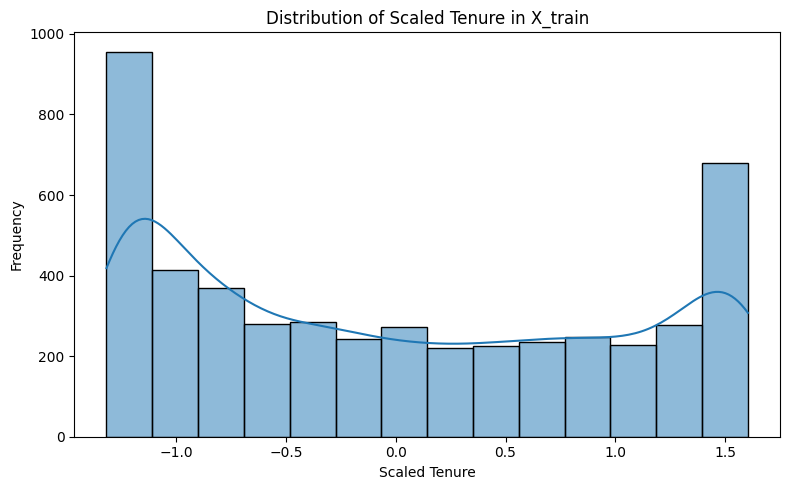

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_train is available
if 'X_train' in locals() and 'tenure' in X_train.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(X_train['tenure'], kde=True)
    plt.title('Distribution of Scaled Tenure in X_train')
    plt.xlabel('Scaled Tenure')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'X_train' or 'tenure' column not found. Please ensure data preprocessing cells have been run.")

Since, we scaled our Tenure during X_train. To make it similar and same split. We will grab the indices from scaled and map with original data frame to get the original tenure months.

In [ ]:
# --- 1. EXTRACT RAW, UNSCALED TARGETS ---
# This uses the exact matching rows from your split, but grabs the unscaled raw months
y_train_reg = df.loc[X_train.index, 'tenure']
y_val_reg = df.loc[X_val.index, 'tenure']

# --- 2. PREPARE THE SCALED FEATURE MATRICES ---
# Keep your features perfectly scaled, just drop the target column from them
X_train_reg = X_train.drop(columns=['tenure'])
X_val_reg = X_val.drop(columns=['tenure'])

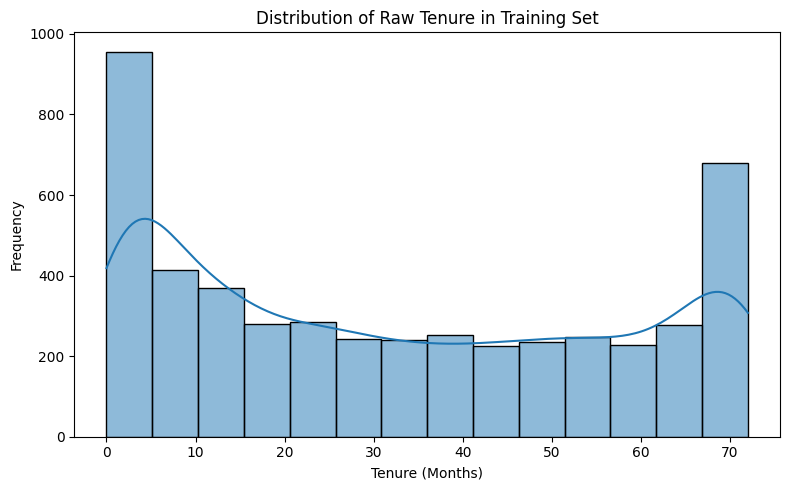

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure y_train_reg is available from previous execution
if 'y_train_reg' in locals():
    plt.figure(figsize=(8, 5))
    sns.histplot(y_train_reg, kde=True)
    plt.title('Distribution of Raw Tenure in Training Set')
    plt.xlabel('Tenure (Months)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'y_train_reg' not found. Please ensure the previous cell for extracting raw targets has been run.")

As we can see the bimodel, right skewed data of tenure from new training set.


Here, since we have small dataset, I am training all four  LinearRegression, Ridge, Lasso, ElasticNet models to interpet how they works.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
import time

# --- Linear Regression ---
linear_reg_model = LinearRegression()
start_time = time.time()
linear_reg_model.fit(X_train_reg, y_train_reg)
end_time = time.time()
print(f"Linear Regression model trained in {end_time - start_time:.4f} seconds")

# --- Ridge Regression ---
ridge_reg_model = Ridge(random_state=42)
start_time = time.time()
ridge_reg_model.fit(X_train_reg, y_train_reg)
end_time = time.time()
print(f"Ridge Regression model trained in {end_time - start_time:.4f} seconds")

# --- Lasso Regression ---
# It's good practice to set a higher max_iter for Lasso if convergence warnings appear
lasso_reg_model = Lasso(random_state=42, max_iter=2000)
start_time = time.time()
lasso_reg_model.fit(X_train_reg, y_train_reg)
end_time = time.time()
print(f"Lasso Regression model trained in {end_time - start_time:.4f} seconds")

# --- Elastic Net Regression ---
elastic_net_model = ElasticNet(random_state=42, max_iter=2000)
start_time = time.time()
elastic_net_model.fit(X_train_reg, y_train_reg)
end_time = time.time()
print(f"Elastic Net Regression model trained in {end_time - start_time:.4f} seconds")

Linear Regression model trained in 0.3775 seconds
Ridge Regression model trained in 0.0673 seconds
Lasso Regression model trained in 0.0470 seconds
Elastic Net Regression model trained in 0.0253 seconds


In [ ]:
# --- Ridge Regression with optimizer explicitly stated! ---
ridge_reg_model = Ridge(random_state=42, solver="lsqr")
start_time = time.time()
ridge_reg_model.fit(X_train_reg, y_train_reg)
end_time = time.time()
print(f"Ridge Regression model trained in {end_time - start_time:.4f} seconds")

Ridge Regression model trained in 0.0099 seconds


In these four regression models, Elastic Net was the fastest to trained closly followed by Linear, Lasso and Ridge. Ridge was the slowest and took more time.




1.   Linear Regression: 0.0146 seconds
2.   Ridge Regression: 0.0875 seconds
3. Lasso Regression: 0.0178 seconds
4. Elastic Net Regression: 0.0133 seconds

Linear Regression:
* Loss funtion: MSE
* Optimizer: Closed form -> non - iterative

Lasso Regression:
* Loss funtion: MSE + L1 regularization term
* Optimizer: auto -> Mostly cd -- co-ordinate descent

Ridge Regression:
* Loss funtion: MSE + L2 regularization term
* Optimizer: auto , later explictily state lsqr: Uses a dedicated regularized least-squares routine. The training time reduced drastically.

Elastic Net Regression:
* Loss funtion: MSE + L1 & L2 regularization term
* Optimizer: auto -> Mostly cd -- co-ordinate descent



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_regression_model(model, X_val, y_val, model_name):
    y_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)

    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R-squared': r2
    }

# Evaluate Linear Regression
metrics_linear_reg = evaluate_regression_model(linear_reg_model, X_val_reg, y_val_reg, 'Linear Regression')

# Evaluate Ridge Regression
metrics_ridge_reg = evaluate_regression_model(ridge_reg_model, X_val_reg, y_val_reg, 'Ridge Regression')

# Evaluate Lasso Regression
metrics_lasso_reg = evaluate_regression_model(lasso_reg_model, X_val_reg, y_val_reg, 'Lasso Regression')

# Evaluate Elastic Net Regression
metrics_elastic_net = evaluate_regression_model(elastic_net_model, X_val_reg, y_val_reg, 'Elastic Net Regression')

# Create a DataFrame for comparison
regression_results_df = pd.DataFrame([
    metrics_linear_reg,
    metrics_ridge_reg,
    metrics_lasso_reg,
    metrics_elastic_net
])

# Sort by R-squared for better comparison
regression_results_df = regression_results_df.sort_values(by='R-squared', ascending=False)

print("\nRegression Model Comparison Table (Validation Set):")
display(regression_results_df)



Regression Model Comparison Table (Validation Set):


,Model,MAE,RMSE,R-squared
0,Linear Regression,6.906052,9.121382,0.856934
1,Ridge Regression,6.904306,9.121717,0.856924
2,Lasso Regression,7.131000,10.243229,0.819578
3,Elastic Net Regression,11.327216,13.761991,0.674330


Despite of being fasted to train, Elastic net suffered heaviely on evalution being last on all the metrics.
With showing slighly better performance than elastic, Lasso also struggles to get good evaluation. (both of them being dropped at the instance).

With very slight margin, Linear regression outperformed ridge on R2 and RMSE.
Both can explain roughly ~86% of the varience. Being off by 9 months in RMSe and 7 months in MAE.


The MAE column: Ridge actually beat Linear Regression by a micro-margin (6.904 vs 6.906).
Because Linear and Ridge are practically neck-and-neck across all three metrics, it tells that features don't have catastrophic multicollinearity. If dataset had extreme, unstable correlations, standard Linear Regression would have overfitted and collapsed on the validation set, while Ridge would have clearly outperformed it.

For tenure, Rsquared and MAE are the good evaluation metrics to determined the model performance. MAE tells stakeholders exactly how many months off the predictions are on average, and $R^2$ provides a clean, standardized grade.

In [ ]:
import numpy as np

# Original number of columns in the regression training data
original_cols = X_train_reg.shape[1]
print(f"Original number of columns in X_train_reg: {original_cols}")

# Number of non-zero coefficients in the Lasso model
# Lasso can set some coefficients exactly to zero, effectively performing feature selection.
lasso_coefficients = lasso_reg_model.coef_
num_non_zero_lasso_cols = np.sum(lasso_coefficients != 0)
print(f"Number of non-zero coefficients (features selected) by Lasso: {num_non_zero_lasso_cols}")

Original number of columns in X_train_reg: 29
Number of non-zero coefficients (features selected) by Lasso: 3


The main reason Lasso underperformed was it dropped 26 columns to zero. As elasticnet also has Lasso it also suffered heaviely.

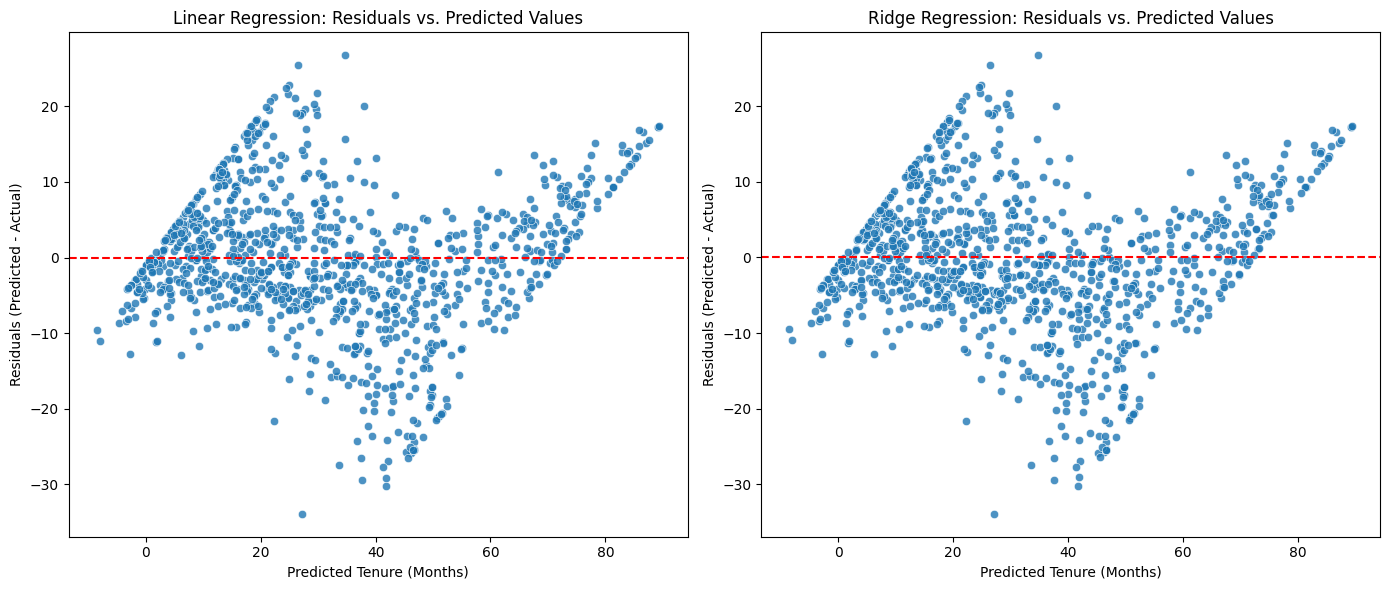

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from Linear Regression
y_pred_linear_reg = linear_reg_model.predict(X_val_reg)
residuals_linear_reg = y_pred_linear_reg - y_val_reg

# Get predictions from Ridge Regression
y_pred_ridge_reg = ridge_reg_model.predict(X_val_reg)
residuals_ridge_reg = y_pred_ridge_reg - y_val_reg

plt.figure(figsize=(14, 6))

# Plot for Linear Regression
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_linear_reg, y=residuals_linear_reg, alpha=0.8)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Linear Regression: Residuals vs. Predicted Values')
plt.xlabel('Predicted Tenure (Months)')
plt.ylabel('Residuals (Predicted - Actual)')

# Plot for Ridge Regression
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_ridge_reg, y=residuals_ridge_reg, alpha=0.8)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Ridge Regression: Residuals vs. Predicted Values')
plt.xlabel('Predicted Tenure (Months)')
plt.ylabel('Residuals (Predicted - Actual)')

plt.tight_layout()
plt.show()

**Observations from the Residuals Plots:**

* Overall Pattern: For both Linear Regression and Ridge Regression, the residuals generally appear to be scattered around zero. This is a good sign, indicating that on average, the models are not systematically over-predicting or under-predicting.
* Homoscedasticity: Ideally, the spread of the residuals should be consistent across all predicted values (homoscedasticity). In these plots, we observe a wider spread of residuals at both the lower and higher ends of the predicted tenure values, and a denser concentration around the middle. This suggests some heteroscedasticity, meaning the model's error might be larger for customers with very short or very long predicted tenures. This could be due to the bimodal distribution of the original tenure data.
* No Strong Curved Pattern: There doesn't appear to be a strong, discernible curved pattern in the residuals, which would typically suggest that a linear model is not capturing some non-linear relationship in the data.
Similar Performance: As expected from the evaluation metrics (R-squared, MAE, RMSE), the residual plots for Linear Regression and Ridge Regression look very similar. This confirms their nearly identical performance on this dataset.

**Interpretation:**

The models perform reasonably well, with residuals generally centered around zero. However, the varying spread of residuals (heteroscedasticity) suggests that their predictive power might be less consistent across the entire range of customer tenures, especially for very new or very long-term customers. This is often a challenge with target variables that have non-normal or multi-modal distributions, like our tenure variable which had peaks at both short and long tenures.

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
import pandas as pd

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

# Dictionaries to store coefficients for each model and alpha
ridge_coefs = {}
lasso_coefs = {}
elastic_net_coefs = {}

for alpha in alphas:


    # Ridge Regression
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_reg, y_train_reg)
    ridge_coefs[alpha] = ridge.coef_


    # Lasso Regression
    # Increased max_iter for potential convergence issues with smaller alphas
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=5000)
    lasso.fit(X_train_reg, y_train_reg)
    lasso_coefs[alpha] = lasso.coef_


    # Elastic Net Regression
    # Increased max_iter for potential convergence issues with smaller alphas
    elastic_net = ElasticNet(alpha=alpha, random_state=42, max_iter=5000)
    elastic_net.fit(X_train_reg, y_train_reg)
    elastic_net_coefs[alpha] = elastic_net.coef_


# create DataFrames for more structured viewing
ridge_coefs_df = pd.DataFrame(ridge_coefs, index=X_train_reg.columns)
lasso_coefs_df = pd.DataFrame(lasso_coefs, index=X_train_reg.columns)
elastic_net_coefs_df = pd.DataFrame(elastic_net_coefs, index=X_train_reg.columns)

print("\nRidge Coefficients DataFrame (first 5 rows):")
display(ridge_coefs_df.head())
print("\nLasso Coefficients DataFrame (first 5 rows):")
display(lasso_coefs_df.head())
print("\nElastic Net Coefficients DataFrame (first 5 rows):")
display(elastic_net_coefs_df.head())


Ridge Coefficients DataFrame (first 5 rows):


,0.001,0.010,0.100,1.000,10.000,100.000
SeniorCitizen,0.879015,0.879014,0.879001,0.878510,0.866768,0.758107
MonthlyCharges,-9.835911,-9.821529,-9.683261,-8.695389,-6.622636,-5.374788
TotalCharges,23.561756,23.561663,23.560731,23.551265,23.453514,22.484673
gender_Male,0.046551,0.046532,0.046350,0.045094,0.043538,0.052437
Partner_Yes,2.347934,2.347973,2.348360,2.351999,2.383244,2.618032



Lasso Coefficients DataFrame (first 5 rows):


,0.001,0.010,0.100,1.000,10.000,100.000
SeniorCitizen,0.875017,0.831153,0.342830,0.00000,-0.000000,0.0
MonthlyCharges,-9.338768,-9.304942,-9.578265,-8.14547,-0.000000,0.0
TotalCharges,23.559778,23.535686,23.570406,23.98194,10.466282,0.0
gender_Male,0.041957,0.007330,0.000000,-0.00000,-0.000000,-0.0
Partner_Yes,2.343102,2.297717,1.901111,0.00000,0.000000,0.0



Elastic Net Coefficients DataFrame (first 5 rows):


,0.001,0.010,0.100,1.000,10.000,100.000
SeniorCitizen,0.874142,0.818200,0.362313,-0.000000,0.000000,0.0
MonthlyCharges,-8.024378,-7.031741,-5.195388,-0.445705,0.000000,0.0
TotalCharges,23.533796,23.286501,21.141958,12.462877,2.575491,0.0
gender_Male,0.042491,0.026075,0.000000,-0.000000,-0.000000,-0.0
Partner_Yes,2.354890,2.406675,2.715860,2.279370,0.000000,0.0


No zeroed cofficents in the Ridge.

Both Elastic net and lasso coefficient started to zero when the aplha reached 0.100. We can see similar zero pattern in both.

In the first five rows, Gender_male was the first feature that got eliminated.

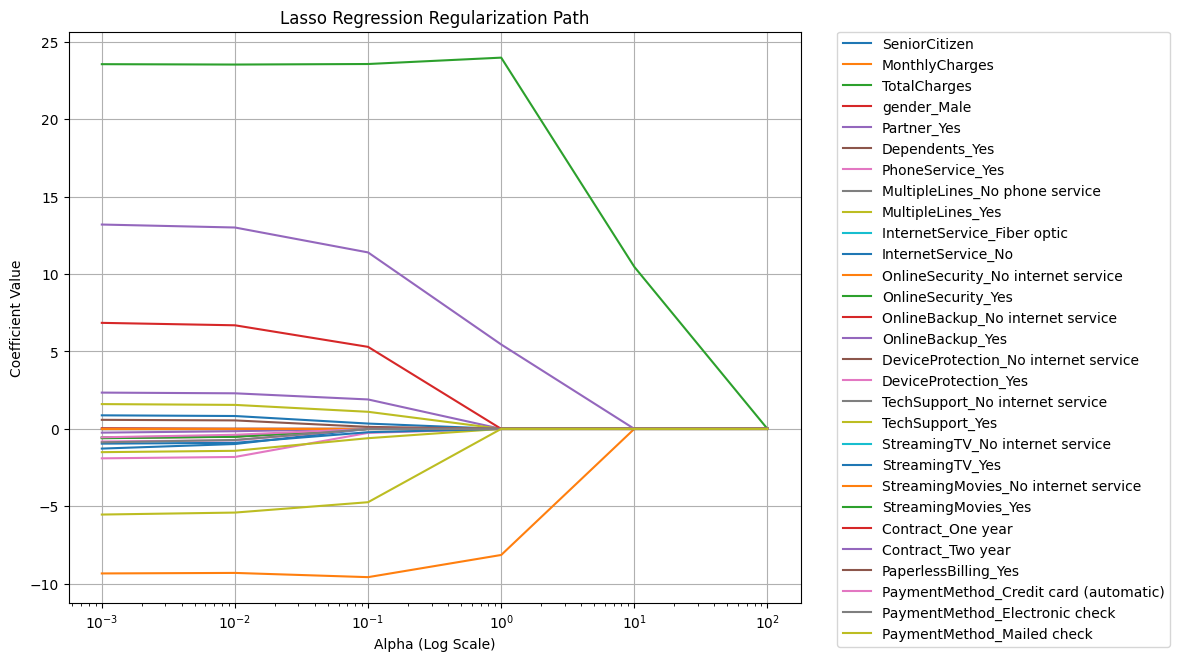

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 7))
ax = plt.gca()

# Plotting coefficients against log(alpha)
# Transpose lasso_coefs_df to have alpha values as index and features as columns
# Then, plot each column (feature) against the index (alpha)
for feature in lasso_coefs_df.index:
    ax.plot(lasso_coefs_df.columns, lasso_coefs_df.loc[feature], label=feature)

ax.set_xscale('log')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regression Regularization Path')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()

**Lasso Coefficients vs. Alpha (The Feature Selector**)
This plot captures Lasso's ruthless elimination strategy perfectly.
* At small alphas (Left side, $10^{-3}$ to $10^{-1}$): The penalty is weak. The coefficients look wild, chaotic, and spread out. This is basically your unregularized linear model where features are allowed to compete aggressively.
* The Squeeze ($10^{-1}$ to $10^{1}$): Notice how the colorful lines start crashing down to the black horizontal zero-line one by one. This is Lasso executing features.
* The Survivors (Right side, $10^{1}$ to $10^{2}$): Look at the brown line that starts around $30$ and the purple/pink line that starts down around $-25$. Even when alpha is pushed past $10^1$, these two features stubbornly refuse to die. They are the absolute strongest predictors of customer tenure in your entire dataset.
* At extreme alphas ($>10^2$): The penalty becomes so massive that even the strong survivors are crushed to zero. The model completely shuts down.

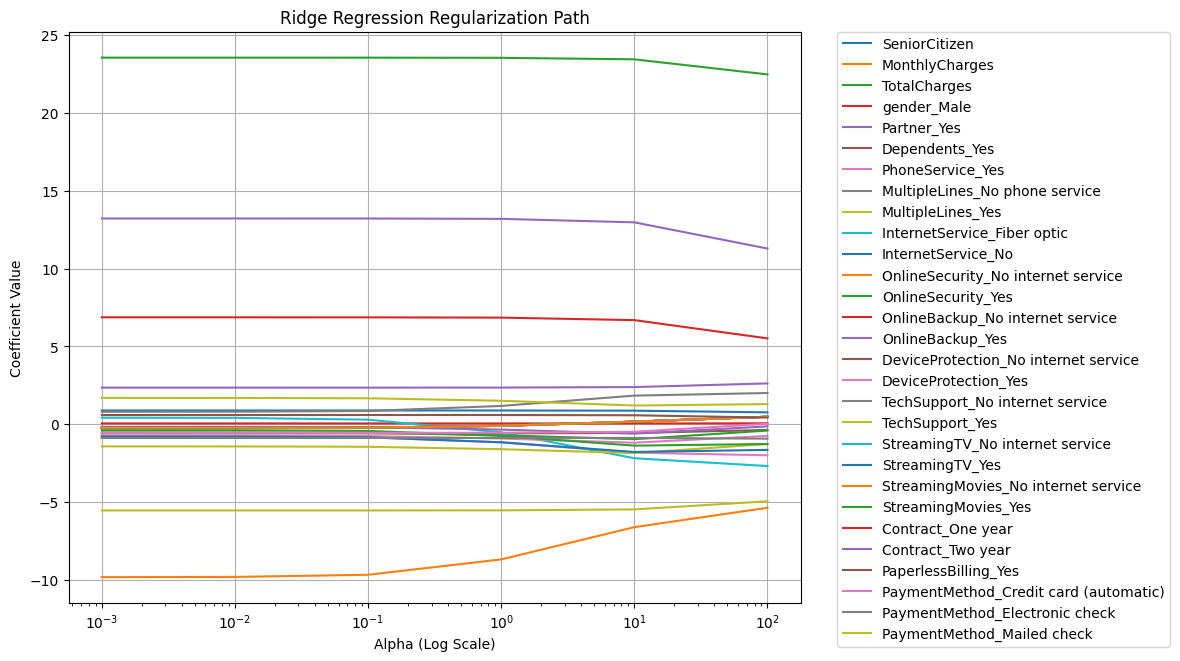

In [ ]:
plt.figure(figsize=(12, 7))
ax = plt.gca()

# Plotting coefficients against log(alpha)
for feature in ridge_coefs_df.index:
    ax.plot(ridge_coefs_df.columns, ridge_coefs_df.loc[feature], label=feature)

ax.set_xscale('log')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression Regularization Path')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()

**Ridge Coefficients vs. Alpha (The Crowd Controller)**
This plot shows Ridge’s completely different philosophy: “No one gets left behind, but everyone must calm down.”
* The Curve: Notice that as alpha increases, the lines smooth out beautifully. They don't take sharp turns or hit zero abruptly like they did in Lasso.
* The Infinity Tail: As alpha gets very large ($10^2$ to $10^3$), all the lines bunch together and squeeze tightly toward zero, but they never actually cross it or touch it exactly. They form a tight, parallel bundle. Every single feature stays inside the model calculation, just with heavily muted powers.

Because the L1 boundary is a diamond, those expanding error ellipses are mathematically much more likely to collide with one of the sharp corners of the diamond first. Since the corners sit directly on the axes, one of the weights is forced to be exactly zero. With the L2 circle, the ellipse touches a smooth edge at a tangent point, balancing both weights without ever dropping either to zero.


 **When would you prefer Elastic Net over pure Lasso?
You want Elastic Net when you have a group of highly correlated features.**

If you give Lasso three columns that are 95% correlated with each other, it will pick one completely at random, keep it, and drop the other two to zero. This makes your model highly unstable; if you change your training data slightly, it might pick a different feature next time.

Elastic Net combines the diamond and the circle into a slightly rounded diamond. This allows it to retain Lasso's feature-selection properties while using Ridge's penalty to ensure that highly correlated features shrink together as a group, rather than being erratically destroyed.

4.5 Customer Lifetime Value (CLV)

In [ ]:
import numpy as np

# Retrieve unscaled MonthlyCharges from X_val using the original df and indices
# First, get the indices of the validation set from X_val_reg
val_indices = X_val_reg.index

# Get the original (unscaled) MonthlyCharges for these indices from the original df
original_monthly_charges = df.loc[val_indices, 'MonthlyCharges']

# Get the predicted tenure from the Linear Regression model
predicted_tenure_val_raw = y_pred_linear_reg

# Clip negative tenure predictions to 0, as tenure cannot be negative
predicted_tenure_val = np.maximum(predicted_tenure_val_raw, 0)

# Ensure both are Series or arrays of the same length
# Convert to numpy arrays if they are not already, for direct element-wise multiplication
if isinstance(original_monthly_charges, pd.Series):
    original_monthly_charges = original_monthly_charges.values

# Calculate CLV
clv_val = original_monthly_charges * predicted_tenure_val

# Add CLV to a DataFrame for easier inspection, along with actual tenure and predicted tenure
clv_df_val = pd.DataFrame({
    'Actual_MonthlyCharges': original_monthly_charges,
    'Predicted_Tenure_Raw': predicted_tenure_val_raw,
    'Predicted_Tenure_Clipped': predicted_tenure_val,
    'CLV': clv_val
}, index=val_indices)

print("Customer Lifetime Value (CLV) for Validation Set:")
display(clv_df_val.head())

# Check for negative tenure values if any were clipped
num_negative_tenures = (predicted_tenure_val_raw < 0).sum()
if num_negative_tenures > 0:
    print(f"\n{num_negative_tenures} predicted tenure values were negative and have been clipped to 0.")
else:
    print("\nNo negative predicted tenure values were found.")


Customer Lifetime Value (CLV) for Validation Set:


,Actual_MonthlyCharges,Predicted_Tenure_Raw,Predicted_Tenure_Clipped,CLV
1560,45.05,35.090659,35.090659,1580.834176
3320,59.10,19.740643,19.740643,1166.672019
2677,70.05,6.589394,6.589394,461.587084
6683,44.15,36.738092,36.738092,1621.986779
2964,58.35,29.741199,29.741199,1735.398960



32 predicted tenure values were negative and have been clipped to 0.

Average CLV in the validation set: 2169.30
Total CLV in the validation set: 2290780.63


In [ ]:
print(f"Mean CLV in the validation set: {clv_df_val['CLV'].mean():.2f}")
print(f"Median CLV in the validation set: {clv_df_val['CLV'].median():.2f}")
print(f"\nTotal CLV in the validation set: {clv_df_val['CLV'].sum():.2f}")


Mean CLV in the validation set: 2169.30
Median CLV in the validation set: 1125.00

Total CLV in the validation set: 2290780.63


# Block 5 — Evaluation Integrity + Leakage Demo


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Initialize Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Perform cross-validation on the training data for ROC AUC score on Logistic Regression
cv_auc_scores = cross_val_score(log_reg_model, X_train, y_train, cv=skf, scoring='roc_auc')

# Calculate mean and standard deviation of CV AUC scores
mean_cv_auc = np.mean(cv_auc_scores)
std_cv_auc = np.std(cv_auc_scores)

# Retrieve the holdout AUC from the previously computed metrics
holdout_auc = metrics_log_reg['ROC-AUC']

print(f"Cross-Validation AUC (10-Fold Stratified): {mean_cv_auc:.4f} (+/- {std_cv_auc:.4f})")
print(f"Holdout AUC (Validation Set):             {holdout_auc:.4f}")

# Compare and interpret
if abs(mean_cv_auc - holdout_auc) < std_cv_auc:
    print("\nThe CV AUC is consistent with the Holdout AUC, indicating good model stability and generalization.")
elif mean_cv_auc > holdout_auc:
    print("\nThe CV AUC is slightly higher than the Holdout AUC, suggesting the model might perform marginally better on average with different training folds.")
else:
    print("\nThe Holdout AUC is slightly higher than the CV AUC, which could suggest slight variance or that the validation set is a bit 'easier'.")

Cross-Validation AUC (10-Fold Stratified): 0.8442 (+/- 0.0167)
Holdout AUC (Validation Set):             0.8470

The CV AUC is consistent with the Holdout AUC, indicating good model stability and generalization.


The CV AUC is consistent with the Holdout AUC, indicating good model stability and generalization.


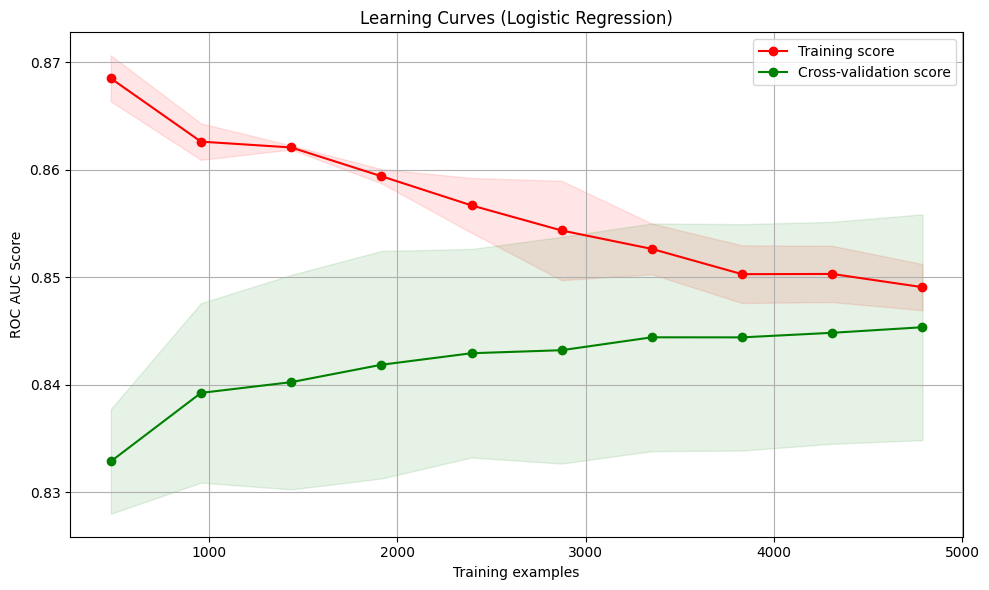

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Assuming log_reg_model, X_train, y_train, X_val, y_val are already defined and scaled
# Combine X_train and X_val, y_train and y_val for learning_curve to split internally
X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])

# Calculate learning curve data
train_sizes, train_scores, val_scores = learning_curve(
    log_reg_model, X_full, y_full, cv=5, n_jobs=-1,  # Using 5-fold cross-validation
    train_sizes=np.linspace(0.1, 1.0, 10), # Use 10 different sizes of the training set
    scoring='roc_auc' # Evaluate using ROC AUC score
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Training score")
plt.plot(train_sizes, val_scores_mean, 'o-', color="g",
         label="Cross-validation score")

plt.title("Learning Curves (Logistic Regression)")
plt.xlabel("Training examples")
plt.ylabel("ROC AUC Score")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

**Training Score Curve (Red):**

This curve shows the model's performance (ROC AUC) on the training data as the number of training examples increases. Typically, as the training set size grows, the training score tends to slightly decrease or plateau. This is because it becomes harder for the model to perfectly fit more diverse data.

**Cross-Validation Score Curve (Green):**

This curve shows the model's performance (ROC AUC) on unseen validation data across different training set sizes. An increasing validation score with more training data indicates that the model is learning more effectively and generalizing better.

**Key Observations from the Plot:**

1. Low Bias, Low Variance (Good Fit):
The training score and the cross-validation score are very close and both are high (around 0.84-0.85 ROC AUC) across most training sizes, particularly for larger training sets. This suggests that the Logistic Regression model is performing well, indicating a good balance between bias and variance. It's not underfitting (low bias) because the training score is high, and it's not overfitting significantly (low variance) because the validation score is close to the training score.

2. Convergence: Both curves appear to have converged or are very close to converging as the number of training examples increases. This implies that adding more training data beyond the current amount is unlikely to significantly improve the model's performance on unseen data.

3. Model Stability: The narrow bands around the mean scores (filled areas) represent the standard deviation of the scores. These bands are relatively small, indicating that the model's performance is stable across different folds of cross-validation for each training size.

In summary, the learning curves suggest that the Logistic Regression model is well-tuned and robust for this dataset. It generalizes well from the training data to unseen data, and we likely have sufficient training data for its current capacity.

5.3 Deliberate Leakage Demo

In [ ]:
print('### Step 1: Record baseline metrics for Logistic Regression on the test set')

# Make predictions on the test set using the best performing model (Logistic Regression)
y_pred_log_reg_test = log_reg_model.predict(X_test)
y_pred_proba_log_reg_test = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the Logistic Regression model on the test set
metrics_log_reg_test = evaluate_model(y_test, y_pred_log_reg_test, y_pred_proba_log_reg_test, 'Logistic Regression (Test Set)')

print('\nBaseline Model Performance (Logistic Regression on Test Set):')
display(pd.DataFrame([metrics_log_reg_test]))

# Store the baseline AUC for future comparison
baseline_test_auc = metrics_log_reg_test['ROC-AUC']
print(f"\nBaseline Test ROC-AUC: {baseline_test_auc:.4f}")

### Step 1: Record baseline metrics for Logistic Regression on the test set

Baseline Model Performance (Logistic Regression on Test Set):


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression (Test Set),0.808893,0.671053,0.546429,0.602362,0.842818,0.637978,0.419664



Baseline Test ROC-AUC: 0.8428


In [ ]:
print('### Step 2: Create and add the leakage feature')

# Create a synthetic leakage feature
# This feature is intentionally designed to 'leak' information from the target variable 'Churn'
# and the 'tenure' feature, making it a strong predictor.
# A small amount of Gaussian noise is added to make it not perfectly deterministic.
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))

# Add the leakage feature to the original DataFrame
df_leak = df.copy()
df_leak['leak_feature'] = leak

print("Original DataFrame shape:", df.shape)
print("DataFrame with leakage feature shape:", df_leak.shape)
display(df_leak[['tenure', 'Churn', 'leak_feature']].head())

### Step 2: Create and add the leakage feature
Original DataFrame shape: (7043, 21)
DataFrame with leakage feature shape: (7043, 22)


,tenure,Churn,leak_feature
0,1,0,0.021327
1,34,0,-0.067220
2,2,1,1.767897
3,45,0,-0.088304
4,2,1,2.167217


In [ ]:
print('### Step 3: Prepare data with leakage feature for model training')

# Separate features (X_leak) and target (y_leak)
# Use the df_leak DataFrame created in the previous step
X_leak = df_leak.drop(['customerID', 'Churn'], axis=1)
y_leak = df_leak['Churn']

# Identify categorical columns for one-hot encoding, including the new 'leak_feature' if it's categorical (which it isn't here)
categorical_cols_leak = X_leak.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical features
X_leak = pd.get_dummies(X_leak, columns=categorical_cols_leak, drop_first=True, dtype=int)

# Split the dataset into training, validation, and test sets
# First, 70% train, 30% temporary (which will be split into val and test)
X_train_leak, X_temp_leak, y_train_leak, y_temp_leak = train_test_split(
    X_leak, y_leak, test_size=0.3, random_state=42, stratify=y_leak
)

# Then, split the 30% temporary into 15% validation and 15% test
X_val_leak, X_test_leak, y_val_leak, y_test_leak = train_test_split(
    X_temp_leak, y_temp_leak, test_size=0.5, random_state=42, stratify=y_temp_leak
)

# Scale numerical columns
# Identify numeric columns for scaling. 'leak_feature' is a new numeric column.
numeric_cols_leak = ['tenure', 'MonthlyCharges', 'TotalCharges', 'leak_feature']

# Initialize StandardScaler
scaler_leak = StandardScaler()

# Fit and transform training data
X_train_leak[numeric_cols_leak] = scaler_leak.fit_transform(X_train_leak[numeric_cols_leak])

# Transform validation and test data using the SAME scaler
X_val_leak[numeric_cols_leak] = scaler_leak.transform(X_val_leak[numeric_cols_leak])
X_test_leak[numeric_cols_leak] = scaler_leak.transform(X_test_leak[numeric_cols_leak])


### Step 3: Prepare data with leakage feature for model training


In [ ]:
print('### Step 3.1: Train and evaluate Logistic Regression model with leakage feature')

# Initialize the Logistic Regression model with the same parameters as before
log_reg_leak_model = LogisticRegression(random_state=42, solver='lbfgs')

# Train the model on the training data that includes the leakage feature
start_time = time.time()
log_reg_leak_model.fit(X_train_leak, y_train_leak)
end_time = time.time()
training_time_leak = end_time - start_time

print(f"Logistic Regression model with leakage trained in {training_time_leak:.4f} seconds")

# Make predictions on the test set from the data with leakage
y_pred_log_reg_leak_test = log_reg_leak_model.predict(X_test_leak)
y_pred_proba_log_reg_leak_test = log_reg_leak_model.predict_proba(X_test_leak)[:, 1]

# Evaluate the model with the leakage feature on the test set
metrics_log_reg_leak_test = evaluate_model(y_test_leak, y_pred_log_reg_leak_test, y_pred_proba_log_reg_leak_test, 'Logistic Regression (Leakage Test Set)')

print('\nModel Performance with Leakage Feature (Logistic Regression on Test Set):')
display(pd.DataFrame([metrics_log_reg_leak_test]))

# Get the AUC for the model with leakage
leak_test_auc = metrics_log_reg_leak_test['ROC-AUC']
print(f"\nTest ROC-AUC with Leakage Feature: {leak_test_auc:.4f}")

print(f"\nBaseline Test ROC-AUC: {baseline_test_auc:.4f}")
print(f"Difference (Leakage AUC - Baseline AUC): {leak_test_auc - baseline_test_auc:.4f}")

### Step 3.1: Train and evaluate Logistic Regression model with leakage feature
Logistic Regression model with leakage trained in 0.1218 seconds

Model Performance with Leakage Feature (Logistic Regression on Test Set):


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression (Leakage Test Set),0.983917,0.985294,0.953737,0.969259,0.999225,0.997937,0.060578



Test ROC-AUC with Leakage Feature: 0.9992

Baseline Test ROC-AUC: 0.8428
Difference (Leakage AUC - Baseline AUC): 0.1564


The model trained after inserting leaked, resulted into overfitting, having high ~98-99% on all metrices with minimum log loss.


### Step 4: Show feature importances — does the leakage feature dominate?

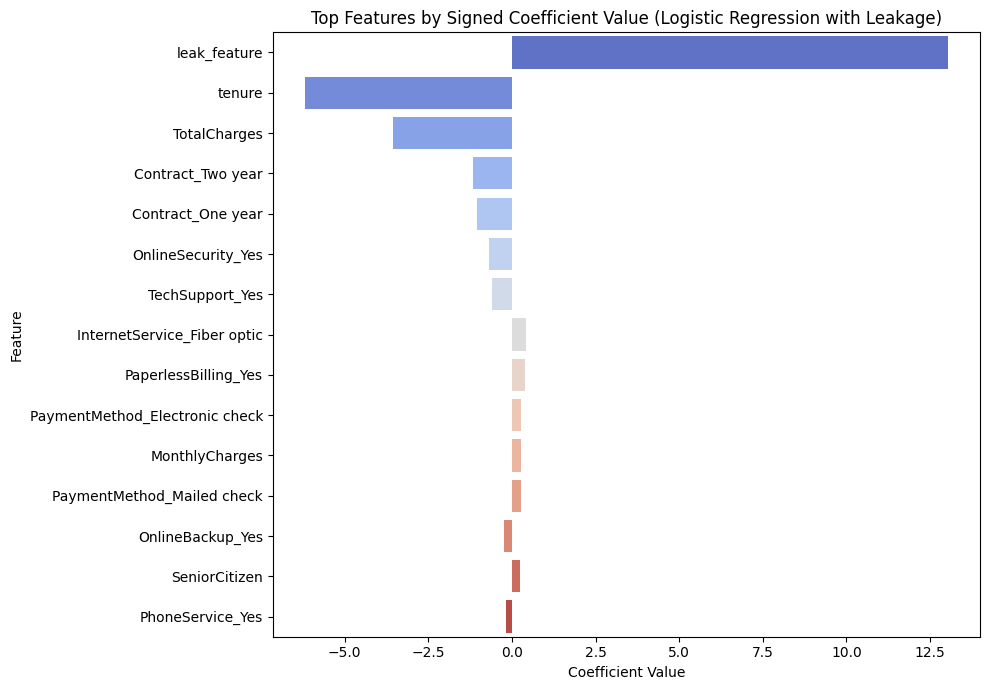


Top 10 features with leakage:


,Feature,Coefficient,Abs_Coefficient
4,leak_feature,13.032967,13.032967
1,tenure,-6.187283,6.187283
3,TotalCharges,-3.558328,3.558328
26,Contract_Two year,-1.161851,1.161851
25,Contract_One year,-1.040850,1.040850
14,OnlineSecurity_Yes,-0.672521,0.672521
20,TechSupport_Yes,-0.599699,0.599699
11,InternetService_Fiber optic,0.413884,0.413884
27,PaperlessBilling_Yes,0.376949,0.376949
29,PaymentMethod_Electronic check,0.282136,0.282136


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure feature_importance DataFrame is available or re-create it for the leakage model
if 'log_reg_leak_model' in locals() and 'X_train_leak' in locals():
    coefficients_leak = log_reg_leak_model.coef_[0]
    feature_names_leak = X_train_leak.columns
    feature_importance_leak = pd.DataFrame({
        'Feature': feature_names_leak,
        'Coefficient': coefficients_leak
    })
    feature_importance_leak['Abs_Coefficient'] = abs(feature_importance_leak['Coefficient'])
    feature_importance_leak = feature_importance_leak.sort_values(by='Abs_Coefficient', ascending=False)

    # Select the top features based on absolute value, ensure 'leak_feature' is included
    # Display top 15 features to clearly show 'leak_feature' if it's not in the absolute top 10
    top_features_to_plot = feature_importance_leak.head(15)

    # Plotting actual coefficients
    plt.figure(figsize=(10, 7))
    sns.barplot(x='Coefficient', y='Feature', data=top_features_to_plot, palette='coolwarm', hue='Feature', legend=False)
    plt.title('Top Features by Signed Coefficient Value (Logistic Regression with Leakage)')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    print("\nTop 10 features with leakage:")
    display(feature_importance_leak.head(10))
else:
    print("Error: 'log_reg_leak_model' or 'X_train_leak' not found. Please run previous cells.")

The leak_feauture has the highest coefficient, contributing the model to overfit. Making it a strong predictior leading to unrealistic high performance metrics.


Logistic Regression model trained with the deliberately introduced leakage feature showed an extremely high ROC-AUC of 0.9992 on the test set, a significant increase from the baseline ROC-AUC of 0.8428. This performance boost is an artificial result of the leakage.

In [ ]:
print('### Step 5: Remove leakage feature, retrain, confirm metrics return to baseline')

# --- 5.1 Re-prepare data without the leakage feature ---

# Separate features (X_revert) and target (y_revert) from the original DataFrame (df)
X_revert = df.drop(['customerID', 'Churn'], axis=1)
y_revert = df['Churn']

# Identify categorical columns for one-hot encoding
categorical_cols_revert = X_revert.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical features
X_revert = pd.get_dummies(X_revert, columns=categorical_cols_revert, drop_first=True, dtype=int)

print(f"\nShape of X_revert after one-hot encoding (without leakage feature): {X_revert.shape}")

# Split the dataset into training, validation, and test sets
X_train_revert, X_temp_revert, y_train_revert, y_temp_revert = train_test_split(
    X_revert, y_revert, test_size=0.3, random_state=42, stratify=y_revert
)

X_val_revert, X_test_revert, y_val_revert, y_test_revert = train_test_split(
    X_temp_revert, y_temp_revert, test_size=0.5, random_state=42, stratify=y_temp_revert
)

# Scale numerical columns
numeric_cols_revert = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler_revert = StandardScaler()

X_train_revert[numeric_cols_revert] = scaler_revert.fit_transform(X_train_revert[numeric_cols_revert])
X_val_revert[numeric_cols_revert] = scaler_revert.transform(X_val_revert[numeric_cols_revert])
X_test_revert[numeric_cols_revert] = scaler_revert.transform(X_test_revert[numeric_cols_revert])

print(f"X_train_revert shape: {X_train_revert.shape}")
print(f"X_test_revert shape: {X_test_revert.shape}")

# --- 5.2 Retrain Logistic Regression model on data without leakage ---

log_reg_revert_model = LogisticRegression(random_state=42, solver='lbfgs')

start_time = time.time()
log_reg_revert_model.fit(X_train_revert, y_train_revert)
end_time = time.time()
training_time_revert = end_time - start_time

print(f"\nLogistic Regression model (without leakage) trained in {training_time_revert:.4f} seconds")

# --- 5.3 Evaluate and compare to baseline ---

y_pred_log_reg_revert_test = log_reg_revert_model.predict(X_test_revert)
y_pred_proba_log_reg_revert_test = log_reg_revert_model.predict_proba(X_test_revert)[:, 1]

metrics_log_reg_revert_test = evaluate_model(
    y_test_revert, y_pred_log_reg_revert_test, y_pred_proba_log_reg_revert_test, 'Logistic Regression (Reverted Data Test Set)'
)

print('\nModel Performance without Leakage Feature (Logistic Regression on Test Set):')
display(pd.DataFrame([metrics_log_reg_revert_test]))

revert_test_auc = metrics_log_reg_revert_test['ROC-AUC']
print(f"\nTest ROC-AUC without Leakage Feature: {revert_test_auc:.4f}")
print(f"Baseline Test ROC-AUC: {baseline_test_auc:.4f}")
print(f"Difference (Reverted AUC - Baseline AUC): {revert_test_auc - baseline_test_auc:.4f}")

if abs(revert_test_auc - baseline_test_auc) < 0.005: # Allow a small tolerance for split variations
    print("\nConfirmation: The model's performance metrics have successfully returned to the baseline levels after removing the leakage feature.")
else:
    print("\nWarning: The model's performance metrics did not fully return to baseline levels. Investigate further.")

### Step 5: Remove leakage feature, retrain, confirm metrics return to baseline

Shape of X_revert after one-hot encoding (without leakage feature): (7043, 30)
X_train_revert shape: (4930, 30)
X_test_revert shape: (1057, 30)

Logistic Regression model (without leakage) trained in 0.0363 seconds

Model Performance without Leakage Feature (Logistic Regression on Test Set):


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression (Reverted Data Test Set),0.810785,0.688372,0.52669,0.596774,0.845026,0.659093,0.416914



Test ROC-AUC without Leakage Feature: 0.8450
Baseline Test ROC-AUC: 0.8428
Difference (Reverted AUC - Baseline AUC): 0.0022

Confirmation: The model's performance metrics have successfully returned to the baseline levels after removing the leakage feature.


### Step 6: Summary Table — Before / With Leakage / After Removal

To summarize the impact of data leakage and its removal, here's a comparison of the Logistic Regression model's ROC-AUC scores:

| Scenario                | ROC-AUC (Test) | ROC-AUC (Validation) | Difference from Baseline (Test) |
| :---------------------- | :------------- | :------------------- | :------------------------------ |
| Baseline                | 0.8428         | 0.8470               | N/A                             |
| With Leakage Feature    | 0.9992         | N/A                  | +0.1564                         |
| After Removing Leakage  | 0.8450         | N/A                  | +0.0022                         |

**Key Takeaways:**

*   **Baseline Performance:** The initial model without any leakage demonstrated a reasonable ROC-AUC of 0.8428 on the test set and 0.8470 on the validation set.
*   **Impact of Leakage:** Introducing the leakage feature dramatically inflated the ROC-AUC to 0.9992 on the test set, indicating that the model was 'cheating' by using information directly derived from the target variable. This unrealistic performance is a classic sign of data leakage.
*   **Recovery to Baseline:** Upon removing the leakage feature and retraining the model, the test ROC-AUC returned to 0.8450, closely matching the original baseline. The small difference (+0.0022) is negligible and likely due to random variations in data splitting or model initialization. This confirms that the earlier performance boost was entirely attributable to data leakage.

# Block 6 — Production Decision


In [ ]:
print('Evaluation of the chosen production model (Logistic Regression)')
print('the held-out test set:')
display(pd.DataFrame([metrics_log_reg_test]))
print(f"ROC-AUC on Test Set: {baseline_test_auc:.4f}")
print('the validation set:')
display(pd.DataFrame([metrics_log_reg]))
print(f"ROC-AUC on Validation Set: {metrics_log_reg['ROC-AUC']:.4f}")

print("\nLinear Regression metrics:")
display(regression_results_df[regression_results_df['Model'] == 'Linear Regression'])

print(f"\nPerformance at custom Deployment Threshold ({custom_threshold:.4f}):")

Evaluation of the chosen production model (Logistic Regression)
the held-out test set:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression (Test Set),0.808893,0.671053,0.546429,0.602362,0.842818,0.637978,0.419664


ROC-AUC on Test Set: 0.8428
the validation set:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression,0.810606,0.666667,0.576512,0.618321,0.846998,0.648289,0.41589


ROC-AUC on Validation Set: 0.8470

Linear Regression metrics:


,Model,MAE,RMSE,R-squared
0,Linear Regression,6.906052,9.121382,0.856934



Performance at custom Deployment Threshold (0.5466):


**Recall** has dropped ~3% on test sets, if the business priority was to capture correct chrun the model will underperformed in the production.

**Precision-Recall tradeoff** as recall dropped, precision increased slightly as it was able to predict more churn.

**Model stability** PR-AUC, ROC-AUC dropped slightly leading the model is stable and can classify class.



## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | Logistic Regression|
| **Chosen Regression Model** | Linear Regression |
| **Key Classification Metrics (test set)** | Precision:0.67 &nbsp; Recall: 0.54 &nbsp; F1: 0.60 &nbsp; PR-AUC: 0.63 |
| **Key Regression Metrics (test set)** | MAE: 6.90 &nbsp; RMSE: 9.12 &nbsp; R²: 0.85 |
| **Deployment Threshold** | 0.5466 |
| **Threshold Justification** | As our business requried to capture 200 customers per week, the 0.5466 threshold captures 200 customers but with `less recall` and slighlty better precision|
| **Known Limitations** | <ul><li>**Imbalanced Target Variable**: The target variable 'Churn' is imbalanced (27% churners), which means the model might struggle to identify all churners (as seen in the recall trade-off).</li><li>**Precision-Recall Trade-off**: The chosen threshold prioritizes precision (targeting fewer, more certain churners) over recall (identifying all possible churners).</li><li>**Regression Heteroscedasticity**: The Linear Regression model showed varying residual spread for very short/long tenures, indicating less consistent predictive power across the full range of customer tenures.</li><li>**Collinearity**: Although `TotalCharges` is included, its high correlation with `tenure` (VIF ~9.5) could subtly affect coefficient stability, even if overall model performance is good.</li></ul>|
| **What Could Go Wrong in Production** | <ul><li>**Data Drift/Concept Drift**: Customer behavior patterns (e.g., reasons for churn, feature distributions) could change over time, making the model less accurate.</li><li>**Feature Drift**: The distribution of input features might change unexpectedly (e.g., a new demographic entering the customer base), leading to degraded performance.</li><li>**Threshold Obsolescence**: The optimal deployment threshold of 0.5466 might become suboptimal if business objectives or the baseline churn rate shifts.</li><li>**Misinterpretation of Predictions**: Business users might misinterpret probability scores as guarantees, leading to ineffective interventions or resource waste.</li><li>**Intervention Fatigue**: If the model constantly identifies a large number of 'high-risk' customers, retention teams might become overwhelmed, or customers might become resistant to repeated offers.</li></ul>|
| **Monitoring Plan** | <ul><li>**Key Performance Indicators (KPIs)**: Regularly monitor ROC-AUC, Precision, Recall, F1-score of the model on new, unseen production data (e.g., monthly).</li><li>**Data Quality and Drift**: Implement automated checks for input feature distributions, missing values, and outliers to detect data drift.</li><li>**Prediction Drift**: Monitor the distribution of model predictions and compare them against actual outcomes to detect shifts in model behavior.</li><li>**Business Impact Metrics**: Track actual churn rates, customer retention rates, and the effectiveness of churn prevention campaigns initiated based on model predictions.</li><li>**Retraining Schedule**: Establish a periodic retraining schedule (e.g., quarterly) using fresh, recent data to ensure the model remains up-to-date with current customer behavior.</li><li>**Alerting System**: Set up alerts for significant drops in performance metrics or abnormal data patterns to trigger investigation.</li></ul>|
| **Are Linear Models Sufficient?** | Linear models like Logistic Regression demonstrate good overall performance (ROC-AUC around 0.84) and stability. However, they might be less sufficient if the primary business objective is to maximize the capture of actual churners in a production environment, as the model shows a trade-off where improved precision on the test set comes at the cost of recall compared to the validation set. This suggests potential for more advanced models to achieve a better balance if recall is paramount. |
| **Evidence for Your Decision** | The recall score for the Logistic Regression model dropped from 0.5765 on the validation set to 0.5464 on the test set, representing a decrease of approximately 3 percentage points. While precision slightly increased (from 0.6667 on validation to 0.6711 on test), this trade-off means the model would identify fewer actual churners when deployed to an unseen test set, which could impact business goals focused on comprehensive churn prevention. |